<style>
    .input_area, .output_area, pre, code {
        white-space: pre-wrap !important;
        word-wrap: break-word !important;
    }
</style>

## Home Owners' Loan Corporation Redlining Analysis for Charlotte, NC

We are examining if neighborhoods, historically graded by the Home Owners' Loan Corporation from 1935 - 1968, show systematically different housing affordability and displacement risk outcomes today. We used geospatial 
joins between HOLC zone boundaries and Charlotte's Neighborhood Profile Areas, 41 NPAs were assigned historical grades. Both actual outcome measures and model predictions, which were generated independently without 
HOLC grade as a feature, were compared across grades using visualizations and Kruskal-Wallis tests. The consistency of findings across all four metrics suggests that the structural disadvantages encoded in Charlotte's redlining maps remain statistically detectable in neighborhood outcomes... even nearly a century later.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from sklearn.preprocessing import StandardScaler
import sqlite3 as db
import warnings
warnings.filterwarnings("ignore")

Query the data from our database and join tables

In [14]:
# Load the data
conn = db.connect("../data/charlotte_housing.db")

master_holc = pd.read_sql_query("""
    SELECT
        m.NPA
        , household_income
        , home_ownership
        , rental_houses
        , food_nutrition
        , employment
        , housing_age
        , code_violations
        , foreclosures
        , new_constructions
        , housing_density
        , age_of_residents
        , race_black
        , race_white
        , race_hispanic
        , race_asian
        , race_other
        , transit_proximity
        , financial_proximity
        , grocery_proximity
        , housing_cost_burden
        , displacement_risk
        , crime_total
        , h.grade
        , h.grade_category
        , p.xgb_proba
        , p.xgb_pred
        , g.gam_predicted_burden
    FROM master AS m
    LEFT JOIN npa_holc AS h 
        ON m.NPA = h.NPA
    LEFT JOIN xgb_predictions AS p
        ON m.NPA = p.NPA
    LEFT JOIN gam_predictions AS g
        ON m.NPA = g.NPA
""", conn)

conn.close()

display(master_holc.head())

,NPA,household_income,home_ownership,rental_houses,food_nutrition,employment,housing_age,code_violations,foreclosures,new_constructions,...,financial_proximity,grocery_proximity,housing_cost_burden,displacement_risk,crime_total,grade,grade_category,xgb_proba,xgb_pred,gam_predicted_burden
0,2,-0.407371,-0.685002,-0.163924,0.240595,0.088074,1.908974,0.229973,-0.351833,-0.303270,...,-0.292939,0.376054,0.278606,0,0.581649,None,None,0.082315,0,0.328171
1,3,0.436290,-0.677445,1.314855,-0.957022,0.482288,2.089046,0.106927,-0.351833,1.549196,...,10.992720,9.194680,0.284134,0,3.480599,C,Definitely Declining,0.032427,0,0.248723
2,4,3.586770,1.531572,-0.911621,-1.108914,0.555413,0.408373,-0.631352,-0.351833,-0.284652,...,-0.551553,-0.673864,0.151362,0,-0.618596,None,None,0.009357,0,0.055263
3,5,-0.868820,-1.245985,-0.172231,1.777049,-1.885547,1.368758,0.845205,-0.351833,0.134247,...,-0.546764,-0.750563,0.313884,1,-0.264850,C,Definitely Declining,0.986389,1,0.460331
4,6,-1.107639,-0.946507,1.937935,1.169478,0.914241,1.728902,1.337391,5.110524,-0.154328,...,0.062656,-0.143792,0.633077,1,1.814352,C,Definitely Declining,0.988906,1,0.506880


Here, we're only going to focus on NPAs that have HOLC grades assigned to them.

In [15]:
# Filter to only NPAs with HOLC grade
holc_df = master_holc[master_holc["grade"].notna()].copy()

print(f"HOLC-graded NPAs: {holc_df.shape[0]}")
print(f"\nGrade distribution:")
print(holc_df["grade"].value_counts().sort_index())

print(f"\nsample by grade:")
print(holc_df.groupby("grade")[["housing_cost_burden", "gam_predicted_burden", 
                                  "xgb_proba", "displacement_risk"]].mean().round(4))

HOLC-graded NPAs: 41

Grade distribution:
grade
A     2
B     5
C    16
D    18
Name: count, dtype: int64

sample by grade:
       housing_cost_burden  gam_predicted_burden  xgb_proba  displacement_risk
grade                                                                         
A                   0.1827                0.0859     0.0199             0.0000
B                   0.2065                0.2093     0.0218             0.0000
C                   0.3766                0.3719     0.6759             0.7500
D                   0.3829                0.3708     0.5482             0.6111


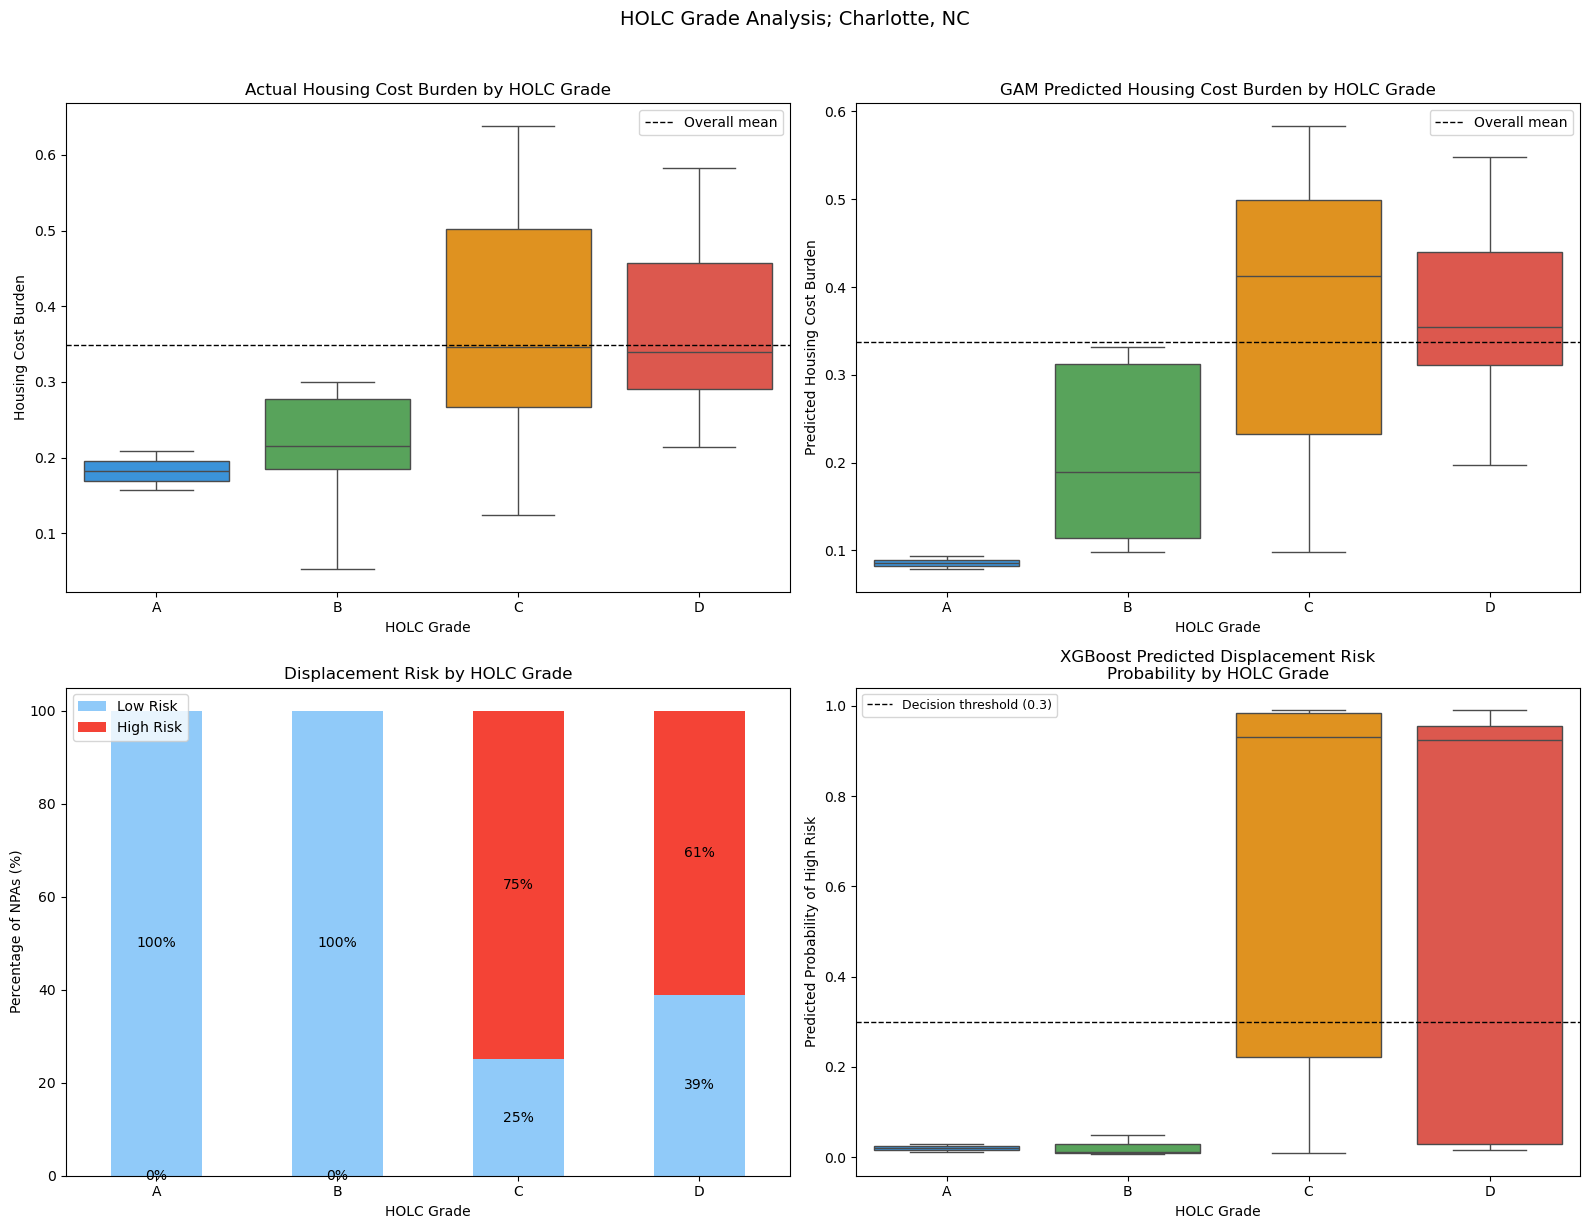

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Actual housing cost burden by grade
sns.boxplot(
    data=holc_df, x="grade", y="housing_cost_burden",
    order=["A", "B", "C", "D"],
    palette={"A": "#2196F3", "B": "#4CAF50", "C": "#FF9800", "D": "#F44336"},
    ax=axes[0, 0]
)
axes[0, 0].set_title("Actual Housing Cost Burden by HOLC Grade")
axes[0, 0].set_xlabel("HOLC Grade")
axes[0, 0].set_ylabel("Housing Cost Burden")
axes[0, 0].axhline(holc_df["housing_cost_burden"].mean(),
                   color="black", linestyle="--", lw=1, label="Overall mean")
axes[0, 0].legend()

# GAM predicted burden by grade
sns.boxplot(
    data=holc_df, x="grade", y="gam_predicted_burden",
    order=["A", "B", "C", "D"],
    palette={"A": "#2196F3", "B": "#4CAF50", "C": "#FF9800", "D": "#F44336"},
    ax=axes[0, 1]
)
axes[0, 1].set_title("GAM Predicted Housing Cost Burden by HOLC Grade")
axes[0, 1].set_xlabel("HOLC Grade")
axes[0, 1].set_ylabel("Predicted Housing Cost Burden")
axes[0, 1].axhline(holc_df["gam_predicted_burden"].mean(),
                   color="black", linestyle="--", lw=1, label="Overall mean")
axes[0, 1].legend()

# Stacked bar chart: displacement risk by grade
risk_counts = holc_df.groupby(["grade", "displacement_risk"]).size().unstack(fill_value=0)
risk_pct = risk_counts.div(risk_counts.sum(axis=1), axis=0) * 100
risk_pct = risk_pct.reindex(["A", "B", "C", "D"])

risk_pct.plot(
    kind="bar", stacked=True,
    color=["#90CAF9", "#F44336"],
    ax=axes[1, 0],
    width=0.5
)
axes[1, 0].set_title("Displacement Risk by HOLC Grade")
axes[1, 0].set_xlabel("HOLC Grade")
axes[1, 0].set_ylabel("Percentage of NPAs (%)")
axes[1, 0].set_xticklabels(["A", "B", "C", "D"], rotation=0)
axes[1, 0].legend(["Low Risk", "High Risk"], loc="upper left")

for bar_group in axes[1, 0].containers:
    axes[1, 0].bar_label(bar_group, fmt="%.0f%%", label_type="center", fontsize=10)

# XGBoost predicted probability by grade
sns.boxplot(
    data=holc_df, x="grade", y="xgb_proba",
    order=["A", "B", "C", "D"],
    palette={"A": "#2196F3", "B": "#4CAF50", "C": "#FF9800", "D": "#F44336"},
    ax=axes[1, 1]
)
axes[1, 1].set_title("XGBoost Predicted Displacement Risk\nProbability by HOLC Grade")
axes[1, 1].set_xlabel("HOLC Grade")
axes[1, 1].set_ylabel("Predicted Probability of High Risk")
axes[1, 1].axhline(0.3, color="black", linestyle="--", lw=1, 
                   label="Decision threshold (0.3)")
axes[1, 1].legend(fontsize=9)

plt.suptitle("HOLC Grade Analysis; Charlotte, NC", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Visual Analysis

These four plots look at the relationship between historical HOLC grade and 
present-day outcomes from different angles. Two using actual measured values 
and two using model predictions generated independently without HOLC grade as 
a feature.

**Actual and GAM Predicted Housing Cost Burden**

Both plots reveal a consistent A to D gradient, with grades A and B falling far
below the overall mean compared to grades C and D. The GAM 
predictions closely reflect actual values for grades B, C, and D. This validates
that the model generalizes reliably to graded neighborhoods specifically, and 
not just the full dataset. Notably, grade A, where the GAM under-predicts burden 
relative to actual values, is likely a result of the extremely small sample size (n=2). 
Grade C shows the widest spread in both plots. This reinforces the interpretation that C-graded neighborhoods 
are likely in some transitional phase, with some still affordable and others already under significant pressure.

**Displacement Risk by HOLC Grade**

Grades A and B are composed entirely of Low Risk neighborhoods. Grade C shows a huge shift, with 75% classified as High Risk. 
Surprisingly, this is a much larger proportion than grade D at 61%. It suggests C neighborhoods may be 
experiencing gentrification pressure as development gradually encroaches deeper into the neighborhood, while some D neighborhoods have been chronically disinvested for so long that market pressure probably has not reached them yet.

**XGBoost Predicted Displacement Risk Probability by HOLC Grade**

The XGBoost probability plot provides the most granular view of displacement 
risk across grades. Grades A and B show near-zero predicted probabilities with 
almost no variance. The model is confident these neighborhoods are low risk. Grades C and D both jump sharply above the 0.3 decision threshold, with 
grade C showing a higher median predicted probability than D (0.676 vs 0.548). This is consistent with the binary displacement risk findings.

However, the wide IQR for D needs to be addressed here. Grade D contains 
18 NPAs that experienced divergent trajectories. Some are probably experiencing active displacement pressure with predicted probabilities approaching 
1.0. Others are grouped near the 0.3 threshold. This reflects chronic disinvestment without the gentrification pressure.

### Statistical Testing: Kruskal-Wallis

To determine whether the differences observed across HOLC grades are 
statistically significant, we apply the 
Kruskal-Wallis test to each outcome variable. The Kruskal-Wallis test is 
a rank-based method that determines if two or more independent 
groups come from the same distribution. It works by ranking all observations together and testing 
whether those ranks are randomly distributed across groups or if they are systematically concentrated in one.

ANOVA was considered but ruled out for a couple of reasons. First, ANOVA assumes 
that the data within each group is normally distributed. We can't assume this with only 2 A-graded and 5 B-graded NPAs. 
Also, ANOVA assumes equal or approximately equal group variances. The 
unequal group sizes (A=2, B=5, C=16, D=18) would make this difficult. Kruskal-Wallis does not make neither assumption It only requires that 
observations are independent and measured on at least an ordinal scale, which is the case here.

A p-value below a significance level of 0.05 indicates that the differences across grades are 
statistically significant. This means the probability of observing 
differences this large by random chance alone is less than 5%. The test 
is applied separately to each of the four outcome measures: actual housing 
cost burden, actual displacement risk, GAM predicted cost burden, and 
XGBoost predicted displacement risk probability.

In [17]:
# Kruskal-Wallis on housing_cost_burden
groups_burden = [
    holc_df[holc_df["grade"] == g]["housing_cost_burden"].values
    for g in ["A", "B", "C", "D"]
]

h_burden, p_burden = kruskal(*groups_burden)
print("=" * 55)
print("Kruskal-Wallis Test: Housing Cost Burden")
print("=" * 55)
print(f"H statistic: {h_burden:.4f}")
print(f"P-value:     {p_burden:.4f}")
print(f"Result:      {'Significant' if p_burden < 0.05 else 'Not significant'}")

# Kruskal-Wallis on displacement_risk
groups_risk = [
    holc_df[holc_df["grade"] == g]["displacement_risk"].values
    for g in ["A", "B", "C", "D"]
]

h_risk, p_risk = kruskal(*groups_risk)
print()
print("=" * 55)
print("Kruskal-Wallis Test: Displacement Risk")
print("=" * 55)
print(f"H statistic: {h_risk:.4f}")
print(f"P-value:     {p_risk:.4f}")
print(f"Result:      {'Significant' if p_risk < 0.05 else 'Not significant'}")

Kruskal-Wallis Test: Housing Cost Burden
H statistic: 9.6994
P-value:     0.0213
Result:      Significant

Kruskal-Wallis Test: Displacement Risk
H statistic: 11.1702
P-value:     0.0108
Result:      Significant


### Kruskal-Wallis Test Results: For Actual Outcome Variables

Both tests returned significant results:

- **Housing Cost Burden**: H=9.70, p=0.0213 : the distribution of actual cost 
  burden differs significantly across HOLC grades
- **Displacement Risk**: H=11.17, p=0.0108 : the distribution of actual 
  displacement risk differs significantly across HOLC grades

These results confirm that the visual gradients observed in the box plot and 
stacked bar chart are statistically reliable and not difference caused by chance 
variation across the 41 HOLC-graded NPAs. Neighborhoods historically graded C 
and D show higher housing cost burden and displacement risk than 
those graded A and B. This suggests that the structural disadvantages encoded in 
Charlotte's HOLC redlining practices between 1935 and 1968 remain statistically 
detectable in neighborhood outcomes today.

In [18]:
# Kruskal-Wallis on GAM predicted burden
groups_gam = [
    holc_df[holc_df["grade"] == g]["gam_predicted_burden"].values
    for g in ["A", "B", "C", "D"]
]

h_gam, p_gam = kruskal(*groups_gam)
print("=" * 55)
print("Kruskal-Wallis Test: GAM Predicted Cost Burden")
print("=" * 55)
print(f"H statistic: {h_gam:.4f}")
print(f"P-value:     {p_gam:.4f}")
print(f"Result:      {'Significant' if p_gam < 0.05 else 'Not significant'}")

# Kruskal-Wallis on XGBoost predicted probability
groups_xgb = [
    holc_df[holc_df["grade"] == g]["xgb_proba"].values
    for g in ["A", "B", "C", "D"]
]

h_xgb, p_xgb = kruskal(*groups_xgb)
print()
print("=" * 55)
print("Kruskal-Wallis Test: XGBoost Predicted Risk Probability")
print("=" * 55)
print(f"H statistic: {h_xgb:.4f}")
print(f"P-value:     {p_xgb:.4f}")
print(f"Result:      {'Significant' if p_xgb < 0.05 else 'Not significant'}")

Kruskal-Wallis Test: GAM Predicted Cost Burden
H statistic: 10.8079
P-value:     0.0128
Result:      Significant

Kruskal-Wallis Test: XGBoost Predicted Risk Probability
H statistic: 11.0052
P-value:     0.0117
Result:      Significant


### Kruskal-Wallis Test Results: Model Predictions

The same tests were performed on the outputs of both predictive models. Again, neither model was trained with HOLC grade as a feature. 
Both learned entirely from neighborhood socioeconomic and structural characteristics.

Both tests again returned significant results:

- **GAM Predicted Cost Burden**: H=10.81, p=0.0128
- **XGBoost Predicted Risk Probability**: H=11.01, p=0.0117

| Outcome | H Statistic | P-Value |
|---------|-------------|---------|
| Actual Housing Cost Burden | 9.70 | 0.0213 |
| Actual Displacement Risk | 11.17 | 0.0108 |
| GAM Predicted Cost Burden | 10.81 | 0.0128 |
| XGBoost Predicted Risk Probability | 11.01 | 0.0117 |

The consistency of significance across all four measures is the key result. 
The models are not restating what the labels say. They are learning 
from neighborhood characteristics alone and independently arriving at the same 
conclusion the actual data shows. This means the socioeconomic conditions the 
models learned to associate with affordability and displacement risk are 
structured along historical redlining boundaries. It provides strong evidence that the effects of redlining are embedded in Charlotte's 
neighborhoods rather than being an artifact of any single measure.

### Conclusion and Recommendations

**Results**

Neighborhoods historically graded C and D by the Home Owners' Loan Corporation show 
systematically worse outcomes than those graded A and B across all four measures. All four Kruskal-Wallis 
tests were statistically significant (p < 0.05), and the pattern holds whether 
we look at raw data or model predictions generated without knowledge of 
historical grade. The A/B vs C/D divide is clear and consistent. 0% of A and B 
neighborhoods are classified as High Risk, compared to 75% of C and 61% of D.

The four GAM features that most strongly predict housing cost burden (household 
income, home ownership, food nutrition reliance, and age of ) degrade systematically from grade A to grade D.
It explains why the models (which again, were trained on neighborhood characteristics independently) replicate the redlining shifts.

**Recommendations**

Some actionable directions for Charlotte:

Targeted income support should focus on the bottom of the income distribution 
in C and D-graded neighborhoods, where the GAM showed the steepest effect on cost burden. Broad citywide wage policies will have limited impact 
given the diminishing returns above average income levels.

Renter protections are the highest-priority. The negative relationship between home ownership and cost burden, which are consistent across both 
models, confirms that renters bear disproportionate affordability pressure. C-graded neighborhoods, which show the highest displacement risk proportion, 
should be prioritized for just-cause eviction protections and rent stabilization.

Food nutrition reliance can serve as an early warning indicator. The threshold 
effect identified by the GAM, where cost burden spikes only once food 
assistance reliance crosses a certain threshold, means the city can use this 
variable to identify neighborhoods approaching crisis before displacement 
becomes irreversible.

Older residents in D-graded neighborhoods face compounding vulnerability due to fixed incomes in neighborhoods with appreciating housing costs. Property tax 
deferrals and senior-targeted anti-displacement programs in historically redlined areas would address this.

**Limitations**

The analysis is constrained by three structural limitations. First, the sample 
of 41 HOLC-graded NPAs is small and unevenly distributed across grades, 
particularly for A (n=2) and B (n=5), which limits the reliability of 
grade-level comparisons. Second, the data represents a single point in time.
Without longitudinal QoL data it is not possible to distinguish neighborhoods 
actively deteriorating from those stable in disadvantage. Third, the analysis 
demonstrates association between historical grade and present outcomes but 
*cannot establish* that redlining *caused* those outcomes. Other historical factors may contribute independently.